In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Mounted at /content/drive


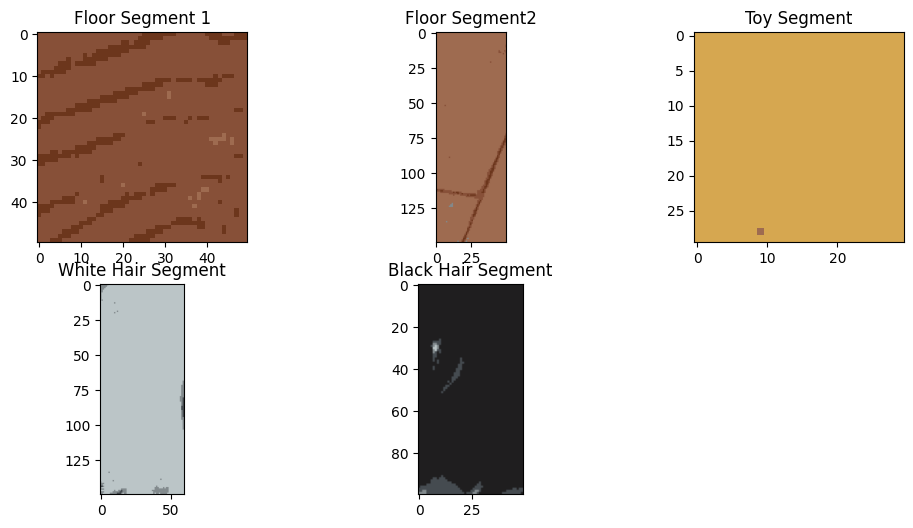

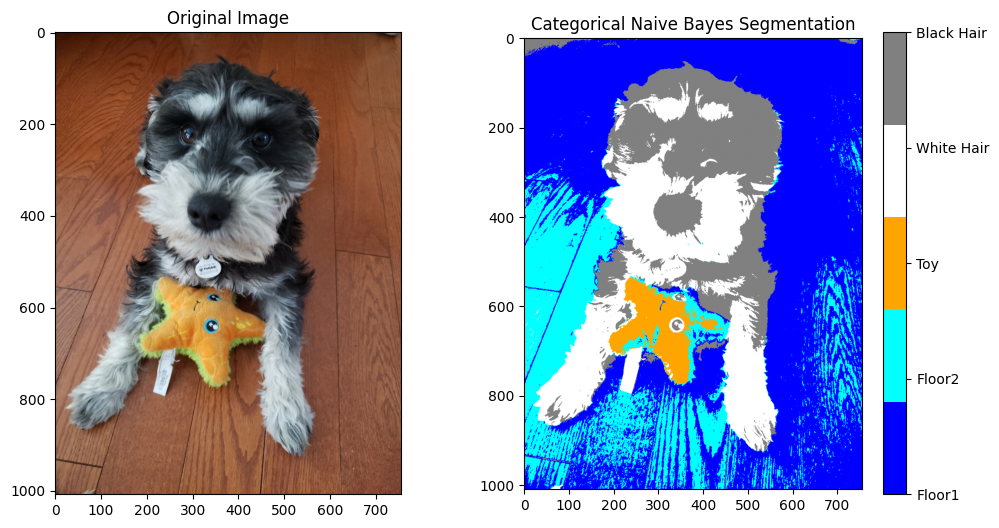

In [ ]:
import numpy as np
from PIL import Image
from sklearn.naive_bayes import GaussianNB, CategoricalNB # Import CategoricalNB
from matplotlib import pyplot as plt
import numpy as np
from os import listdir
import os
import random
from matplotlib.colors import ListedColormap
from sklearn.cluster import MiniBatchKMeans

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

colors = ['blue', 'cyan', 'orange', 'white', 'gray']
work_path = "/content/drive/MyDrive/DigitalImageProcessing/Chapter5/Data"


# Binning or vector quantization process
def bin_image_colors(img, n_colors=8):
    # Convert image to a NumPy array of pixels
    pixels = np.array(img).reshape(-1, 3)

    # Apply MiniBatchKMeans for faster clustering on large images
    kmeans = MiniBatchKMeans(n_clusters=n_colors, random_state=0, n_init=10)
    kmeans.fit(pixels)

    # Get the cluster centers (representative colors)
    binned_colors = kmeans.cluster_centers_.astype(int)

    # Replace each pixel's color with its corresponding cluster center color
    labels = kmeans.predict(pixels)
    binned_pixels = binned_colors[labels]

    # Reshape the binned pixels back to the original image dimensions
    binned_image_array = binned_pixels.reshape(img.size[1], img.size[0], 3)

    return binned_image_array


# Load image
image_path = work_path + "/Dog.jpg"
img = Image.open(image_path).convert("RGB")
img_arr = bin_image_colors(img, n_colors=8)


# Reshape into pixels
h, w, c = img_arr.shape
pixels = img_arr.reshape(-1, 3)

# -----------------------------
# Step 1: Create training labels
# -----------------------------
# Select dog (foreground) and floor (background) samples manually
# (here we just take rectangles for simplicity; you could refine)


floor_region1 = img_arr[150:200, 100:150]    # Example: part of floor
floor_region2 = img_arr[450:600, 50:100]    # Example: part of floor
toy_region = img_arr[590:620, 320:350] # Example: part of toy
white_hair_region = img_arr[300:450, 230:290] # Example: part of white dog hair
black_hair_region = img_arr[200:300, 450:500] # Example: part of black dog hair



# plot labels
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.title("Floor Segment 1")
plt.imshow(floor_region1)
plt.subplot(2,3,2)
plt.title("Floor Segment2")
plt.imshow(floor_region2)
plt.subplot(2,3,3)
plt.title("Toy Segment")
plt.imshow(toy_region)
plt.subplot(2,3,4)
plt.title("White Hair Segment")
plt.imshow(white_hair_region)
plt.subplot(2,3,5)
plt.title("Black Hair Segment")
plt.imshow(black_hair_region)
# plt.show()


# reshape labels
floor_region1 = floor_region1.reshape(-1, 3)
floor_region2 = floor_region2.reshape(-1, 3)
toy_region = toy_region.reshape(-1, 3)
white_hair_region = white_hair_region.reshape(-1, 3)
black_hair_region = black_hair_region.reshape(-1, 3)

# prepare data pairs
X_train = np.vstack([floor_region1, floor_region2, toy_region, white_hair_region, black_hair_region])
y_train = np.hstack([np.zeros(len(floor_region1)), np.ones(len(floor_region2)),  np.full(len(toy_region), 2),
                     np.full(len(white_hair_region), 3), np.full(len(black_hair_region), 4)])

# -----------------------------
# Step 2: Train Naive Bayes
# -----------------------------
clf = CategoricalNB()
clf.fit(X_train, y_train)

# -----------------------------
# Step 3: Predict labels for all pixels
# -----------------------------
y_pred = clf.predict(pixels)
segmented = y_pred.reshape(h, w)

# -----------------------------
# Step 4: Visualization
# -----------------------------
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)

#plt.subplot(1,2,2)
#plt.title("Binned Image")
#plt.imshow(img_arr)

plt.subplot(1,2,2)
plt.title("Categorical Naive Bayes Segmentation")
custom_cmap = ListedColormap(colors)
norm = plt.Normalize(0, 3)
plt.imshow(segmented, cmap=custom_cmap, vmin=0, vmax=4) # Added vmin and vmax for discrete colormap

cbar = plt.colorbar(ticks=[0, 1, 2, 3, 4]) # Added ticks to colorbar
cbar.set_ticklabels(["Floor1", "Floor2", "Toy", "White Hair", "Black Hair"])

plt.show()